# All final plots and analyses for figure 2

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import joblib

### Figure 2A - Heterogenous pseudobulks in training and testing for GrooD models

In [2]:
simple_pb = pd.read_csv('../../grood_runs/revisions/grood_heterogeneity_tests/Hao-2_notarget_pseudobulks_Hao_2_train_for_GRCh37_pseudobulks_only_noMarkers_GCF_000001405.25_GRCh37.p13_genomic_Hao-2_notarget_pseudobulk_proprotions_76606442/evaluation/predictions_merged.csv', index_col=0)
simple_pb['data'] = 'canonical'
indiv_pb = pd.read_csv('../../grood_runs/revisions/grood_heterogeneity_tests/Hao-2_individual_pseudobulks_Hao_2_train_for_GRCh37_pseudobulks_only_noMarkers_GCF_000001405.25_GRCh37.p13_genomic_Hao-2_individual_pseudobulk_proprotions_cf705fe3/evaluation/predictions_merged.csv', index_col=0)
indiv_pb['data'] = 'individual-specific'
cond_pb = pd.read_csv('../../grood_runs/revisions/grood_heterogeneity_tests/Hao-2_condition_pseudobulks_Hao_2_train_for_GRCh37_pseudobulks_only_noMarkers_GCF_000001405.25_GRCh37.p13_genomic_Hao-2_condition_pseudobulk_proprotions_5f150b01/evaluation/predictions_merged.csv', index_col=0)
cond_pb['data'] = 'condition-specific'
cond_pb.head()

,tool,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data
sample,,,,,,,,,
Batch1_sample_1,BayesPrism,0.166637,0.007743,0.003090,0.642888,0.112794,0.022569,0.044279,condition-specific
Batch1_sample_10,BayesPrism,0.219861,0.001658,0.002825,0.137920,0.255278,0.325085,0.057373,condition-specific
Batch1_sample_11,BayesPrism,0.156430,0.012960,0.010235,0.119640,0.549102,0.050445,0.101188,condition-specific
Batch1_sample_12,BayesPrism,0.209296,0.002867,0.006601,0.222850,0.402887,0.085213,0.070286,condition-specific
Batch1_sample_13,BayesPrism,0.044443,0.022534,0.009052,0.720460,0.072874,0.024177,0.106460,condition-specific


In [3]:
simple_gt = pd.read_csv('../../../../17_Deconv_benchmark/runs_for_grood_paper/complete_set_of_runs/pseudobulk_data/pseudobulk_data_random_proportions/Hao-2_notarget_pseudobulk_proprotions.csv', index_col=0)
simple_gt['data'] = 'canonical'
indiv_gt = pd.read_csv('../../../../17_Deconv_benchmark/runs_for_grood_paper/complete_set_of_runs/pseudobulk_data/pseudobulk_data_random_proportions/Hao-2_individual_pseudobulk_proprotions.csv', index_col=0)
indiv_gt['data'] = 'individual-specific'
cond_gt = pd.read_csv('../../../../17_Deconv_benchmark/runs_for_grood_paper/complete_set_of_runs/pseudobulk_data/pseudobulk_data_random_proportions/Hao-2_condition_pseudobulk_proprotions.csv', index_col=0)
cond_gt['data'] = 'condition-specific'
cond_gt.head()

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data
Batch2_sample_1,0.327968,0.000000,0.012072,0.187123,0.078471,0.376258,0.018109,condition-specific
Batch2_sample_2,0.000000,0.056225,0.028112,0.170683,0.030120,0.688755,0.026104,condition-specific
Batch2_sample_3,0.062374,0.629779,0.022133,0.062374,0.110664,0.102616,0.010060,condition-specific
Batch2_sample_4,0.309859,0.450704,0.016097,0.030181,0.179074,0.000000,0.014085,condition-specific
Batch2_sample_5,0.118712,0.098592,0.002012,0.303823,0.000000,0.450704,0.026157,condition-specific


In [4]:
comb_df = pd.concat([simple_pb, indiv_pb, cond_pb], axis=0)
comb_df['Sample'] = comb_df.index.tolist()
# comb_df.drop(['Unknown'], axis =1, inplace=True)
comb_df

,tool,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data,Sample
sample,,,,,,,,,,
Sample_1,BayesPrism,0.119750,0.151996,0.009522,0.467741,0.224653,0.000294,0.026045,canonical,Sample_1
Sample_10,BayesPrism,0.350895,0.000200,0.000074,0.069513,0.213919,0.365305,0.000094,canonical,Sample_10
Sample_11,BayesPrism,0.334530,0.015358,0.015480,0.362408,0.239354,0.027944,0.004926,canonical,Sample_11
Sample_12,BayesPrism,0.360822,0.112735,0.043851,0.204175,0.110903,0.138891,0.028624,canonical,Sample_12
Sample_13,BayesPrism,0.171574,0.418859,0.058698,0.074662,0.025908,0.199951,0.050349,canonical,Sample_13
...,...,...,...,...,...,...,...,...,...,...
Batch2_sample_5,Scaden,0.101980,0.044623,0.036859,0.234528,0.038992,0.373235,0.169783,condition-specific,Batch2_sample_5
Batch2_sample_6,Scaden,0.067217,0.210518,0.035942,0.150006,0.294740,0.054330,0.187248,condition-specific,Batch2_sample_6
Batch2_sample_7,Scaden,0.318135,0.047407,0.031997,0.050722,0.139356,0.258634,0.153747,condition-specific,Batch2_sample_7


In [5]:
comb_gt = pd.concat([simple_gt, indiv_gt, cond_gt], axis=0)
comb_gt['Sample'] = comb_gt.index.tolist()
comb_gt

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data,Sample
Sample_1,0.072435,0.354125,0.012072,0.317907,0.225352,0.000000,0.018109,canonical,Sample_1
Sample_2,0.269076,0.198795,0.028112,0.036145,0.283133,0.158635,0.026104,canonical,Sample_2
Sample_3,0.032193,0.464789,0.022133,0.000000,0.175050,0.295775,0.010060,canonical,Sample_3
Sample_4,0.000000,0.042254,0.016097,0.472837,0.434608,0.020121,0.014085,canonical,Sample_4
Sample_5,0.610442,0.253012,0.002008,0.042169,0.066265,0.000000,0.026104,canonical,Sample_5
...,...,...,...,...,...,...,...,...,...
Batch1_sample_21,0.044266,0.074447,0.462777,0.213280,0.004024,0.030181,0.171026,condition-specific,Batch1_sample_21
Batch1_sample_22,0.110442,0.034137,0.351406,0.122490,0.098394,0.114458,0.168675,condition-specific,Batch1_sample_22
Batch1_sample_23,0.058586,0.080808,0.036364,0.032323,0.466667,0.216162,0.109091,condition-specific,Batch1_sample_23
Batch1_sample_24,0.080321,0.090361,0.018072,0.176707,0.116466,0.371486,0.146586,condition-specific,Batch1_sample_24


In [6]:
# Generate QC metrics per cell type and tool

from scipy import stats

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    samples = groundTruth.index.tolist()

    for sample in samples:
        
        xdata = df.loc[sample].tolist()
        ydata = groundTruth.loc[sample].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = samples

    return DF

In [7]:
CELL_COLS = ["B cells","CD4 T cells","CD8 T cells","DC","Monocytes","NK cells","Tregs"]

import numpy as np
import pandas as pd

CELL_COLS = ["B cells","CD4 T cells","CD8 T cells","DC","Monocytes","NK cells","Tregs"]

def align_pred_and_gt_per_row(pred, groundTruth, cell_cols=CELL_COLS):
    """
    Returns:
      X: predictions features (index = pred_row_id)
      Y: ground-truth features replicated to each prediction row (same index)
      meta: metadata per prediction row (tool, Sample, etc.) for later joining
    """

    gt = groundTruth.copy()
    if "Sample" in gt.columns:
        gt = gt.set_index("Sample", drop=False)
    gt_feat = gt[cell_cols].copy()
    gt_feat.columns = [f"{cell_col}_gt" for cell_col in cell_cols]

    p = pred.copy()
    p = p.reset_index(drop=False)
    p["pred_row_id"] = np.arange(len(p), dtype=int)

    if "Sample" not in p.columns:
        raise ValueError("pred must contain a 'Sample' column to merge with groundTruth.")

    m = p.merge(
        gt_feat,
        left_on="Sample",
        right_index=True,
        how="left"
    )

    X = m.set_index("pred_row_id")[cell_cols].copy()

    Y = m.set_index("pred_row_id")[gt_feat.columns.tolist()].copy()

    meta = m.set_index("pred_row_id")[["tool", "Sample"]].copy()
    for c in ["data"]:
        if c in m.columns:
            meta[c] = m.set_index("pred_row_id")[c]

    X = X.reindex(columns=cell_cols)
    Y.columns = [col[:-3] for col in Y.columns.tolist()]
    Y = Y.reindex(columns=cell_cols)

    return X, Y, meta, m

metrics_list = []

X_all, Y_all, meta_all, gt_feat = align_pred_and_gt_per_row(comb_df, comb_gt, cell_cols=CELL_COLS)

for tool, ids in meta_all.groupby("tool").groups.items():
    X = X_all.loc[ids].copy()
    Y = Y_all.loc[ids].copy()

    X.sort_index(axis=1, inplace=True)
    Y.sort_index(axis=1, inplace=True)

    metrics = getCorr(X, Y)
    metrics["Tool"] = tool
    metrics["Sample"] = meta_all.loc[ids, "Sample"].values
    metrics["Pseudobulk"] = meta_all.loc[ids, "data"].values
    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics

,PCC,SCC,CCC,RMSE,RD,MAD,Tool,Sample,Pseudobulk
0,0.787219,0.892857,0.784673,0.096817,-0.059916,0.058679,BayesPrism,Sample_1,canonical
1,0.903882,0.892857,0.892740,0.077265,37.076425,0.053413,BayesPrism,Sample_10,canonical
2,0.926161,0.714286,0.917976,0.057350,0.867533,0.040707,BayesPrism,Sample_11,canonical
3,0.788877,0.857143,0.788737,0.068406,0.010196,0.055411,BayesPrism,Sample_12,canonical
4,0.986289,0.857143,0.929014,0.059060,-0.300675,0.050614,BayesPrism,Sample_13,canonical
...,...,...,...,...,...,...,...,...,...
883,0.904365,0.857143,0.862971,0.073055,-0.130689,0.062133,Scaden,Batch2_sample_5,condition-specific
884,0.736482,0.750000,0.660156,0.097640,-0.160082,0.070902,Scaden,Batch2_sample_6,condition-specific
885,0.894927,0.750000,0.873784,0.058403,0.044265,0.044021,Scaden,Batch2_sample_7,condition-specific
886,0.829666,0.892857,0.758628,0.068852,-0.075124,0.048144,Scaden,Batch2_sample_8,condition-specific


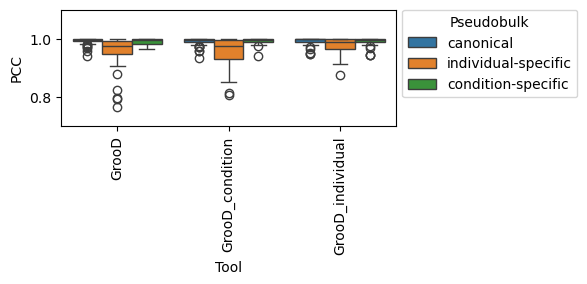

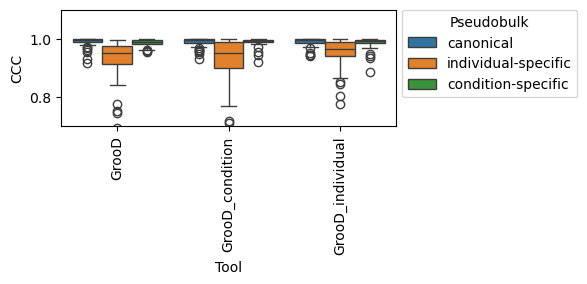

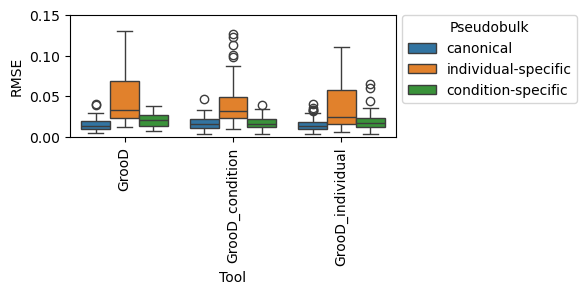

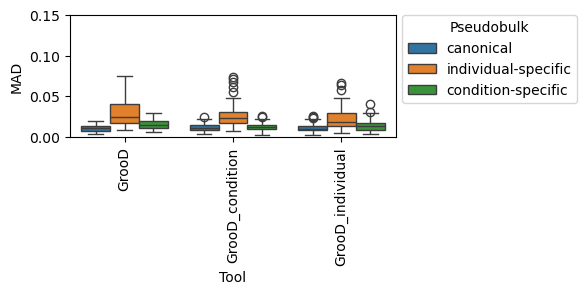

In [8]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df, metric, plot=False):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """

    df.sort_values(by=['Tool'], inplace=True)

    plt.figure(figsize=(6,3))
    p = sns.boxplot(data=df, x = "Tool", y = metric, hue = "Pseudobulk")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    if metric in ['RMSE', 'MAD']:
        p.set_ylim([0,0.15])
    else:
        p.set_ylim([0.7,1.1])
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Pseudobulk')
    plt.tight_layout()
    if plot:
        plt.savefig(f'Figure_2A_{metric}.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(complete_metrics.loc[complete_metrics['Tool'].isin(['GrooD', 'GrooD_condition', 'GrooD_individual'])], 'PCC')
boxplot_metrics(complete_metrics.loc[complete_metrics['Tool'].isin(['GrooD', 'GrooD_condition', 'GrooD_individual'])], 'CCC', True)
boxplot_metrics(complete_metrics.loc[complete_metrics['Tool'].isin(['GrooD', 'GrooD_condition', 'GrooD_individual'])], 'RMSE')
boxplot_metrics(complete_metrics.loc[complete_metrics['Tool'].isin(['GrooD', 'GrooD_condition', 'GrooD_individual'])], 'MAD', True)

SI - comparison to the other tools

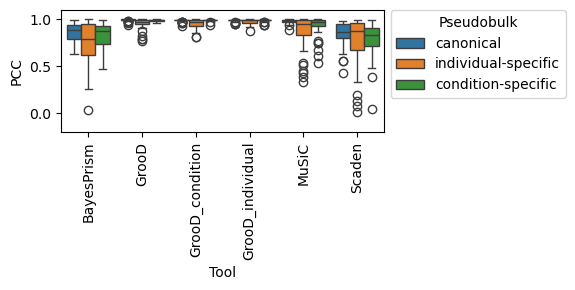

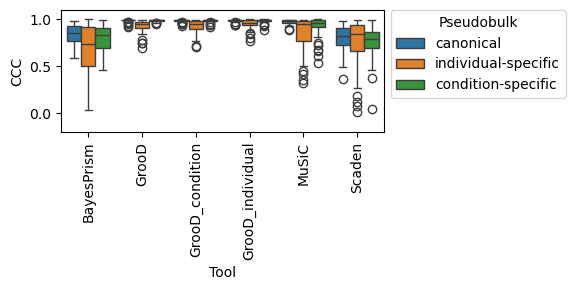

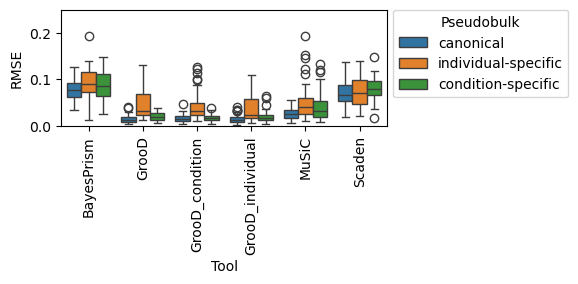

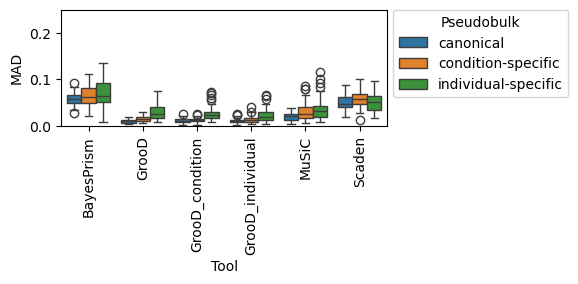

In [9]:
def boxplot_metrics(df, metric, plot=False):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """

    df.sort_values(by=['Tool'], inplace=True)

    plt.figure(figsize=(6,3))
    p = sns.boxplot(data=df, x = "Tool", y = metric, hue = "Pseudobulk")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    if metric in ['RMSE', 'MAD']:
        p.set_ylim([0,0.25])
    else:
        p.set_ylim([-0.2,1.1])
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Pseudobulk')
    plt.tight_layout()
    if plot:
        plt.savefig(f'Figure_SI3A_{metric}.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()


boxplot_metrics(complete_metrics, 'PCC')
boxplot_metrics(complete_metrics, 'CCC', True)
boxplot_metrics(complete_metrics, 'RMSE')
boxplot_metrics(complete_metrics, 'MAD', True)

### Figure 2B

In [10]:
# Generate QC metrics per cell type and tool

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    cellTypes = groundTruth.columns.tolist()

    for cell in cellTypes:

        index_names = df.index.tolist()
        
        xdata = df.loc[index_names, cell].tolist()
        ydata = groundTruth.loc[index_names, cell].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = cellTypes

    return DF


In [11]:
simple_pb

,tool,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data
sample,,,,,,,,,
Sample_1,BayesPrism,0.119750,0.151996,0.009522,0.467741,0.224653,0.000294,0.026045,canonical
Sample_10,BayesPrism,0.350895,0.000200,0.000074,0.069513,0.213919,0.365305,0.000094,canonical
Sample_11,BayesPrism,0.334530,0.015358,0.015480,0.362408,0.239354,0.027944,0.004926,canonical
Sample_12,BayesPrism,0.360822,0.112735,0.043851,0.204175,0.110903,0.138891,0.028624,canonical
Sample_13,BayesPrism,0.171574,0.418859,0.058698,0.074662,0.025908,0.199951,0.050349,canonical
...,...,...,...,...,...,...,...,...,...
Sample_50,Scaden,0.076948,0.091246,0.015538,0.127878,0.263866,0.033577,0.390947,canonical
Sample_6,Scaden,0.260225,0.032632,0.016614,0.107608,0.030478,0.445997,0.106446,canonical
Sample_7,Scaden,0.339491,0.061566,0.018328,0.242544,0.098198,0.037329,0.202545,canonical


In [12]:
simple_gt

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,data
Sample_1,0.072435,0.354125,0.012072,0.317907,0.225352,0.000000,0.018109,canonical
Sample_2,0.269076,0.198795,0.028112,0.036145,0.283133,0.158635,0.026104,canonical
Sample_3,0.032193,0.464789,0.022133,0.000000,0.175050,0.295775,0.010060,canonical
Sample_4,0.000000,0.042254,0.016097,0.472837,0.434608,0.020121,0.014085,canonical
Sample_5,0.610442,0.253012,0.002008,0.042169,0.066265,0.000000,0.026104,canonical
Sample_6,0.270161,0.028226,0.000000,0.165323,0.000000,0.534274,0.002016,canonical
Sample_7,0.398390,0.074447,0.022133,0.408451,0.060362,0.012072,0.024145,canonical
Sample_8,0.128514,0.032129,0.028112,0.522088,0.263052,0.000000,0.026104,canonical
Sample_9,0.282258,0.268145,0.012097,0.000000,0.334677,0.080645,0.022177,canonical
Sample_10,0.260081,0.000000,0.002016,0.052419,0.135081,0.528226,0.022177,canonical


In [13]:
metrics_list = []

for tool in list(set(simple_pb['tool'])):
    
    df = simple_pb.loc[simple_pb['tool'] == tool]
    gt = simple_gt.loc[df.index.tolist(),:]
    gt.drop('data', axis=1, inplace=True)
    df = df[gt.columns.tolist()]

    metrics = getCorr(df, gt)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

,PCC,SCC,CCC,RMSE,RD,MAD,Tool
B cells,0.995577,0.997383,0.995564,0.015275,-0.007523,0.010214,GrooD_individual
CD4 T cells,0.984155,0.982087,0.982239,0.030027,-0.030517,0.021055,GrooD_individual
CD8 T cells,0.993301,0.933519,0.992420,0.010287,-0.016527,0.007160,GrooD_individual
DC,0.996058,0.996542,0.995724,0.014899,-0.080222,0.010908,GrooD_individual
Monocytes,0.993490,0.994982,0.992976,0.016654,0.038989,0.011225,GrooD_individual


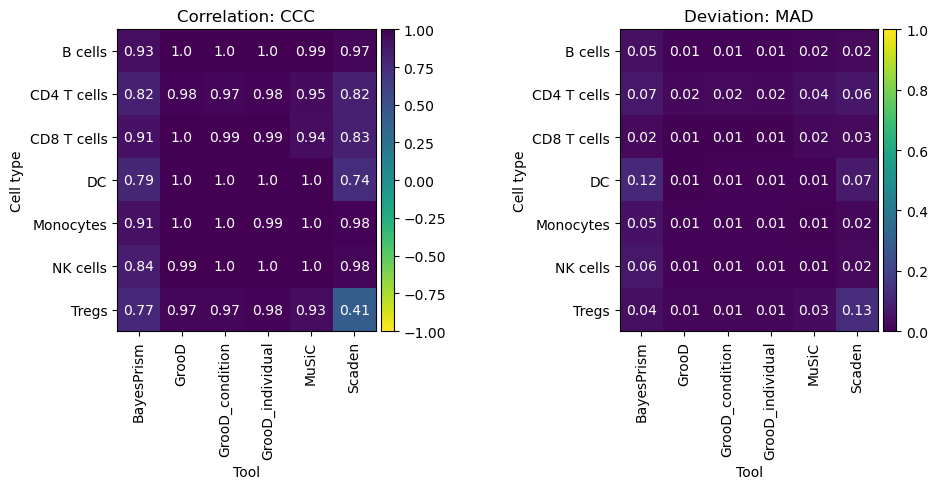

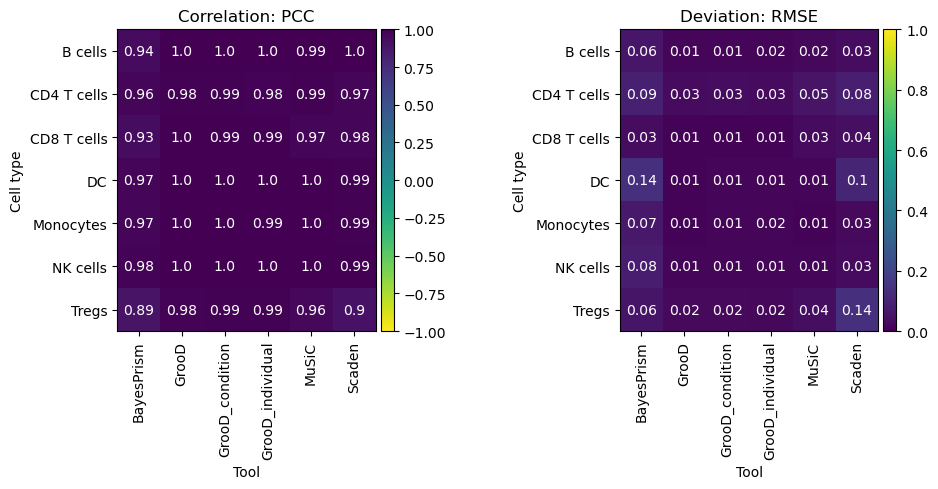

In [14]:
# Changed function for annotated heatmap

def annotated_heatmap(df, m1, m2, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m1]]
        .pivot(index="Cell type", columns="Tool", values=m1)
    )
    df2 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m2]]
        .pivot(index="Cell type", columns="Tool", values=m2)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: {m1}')
    ax1.set_xlabel('Tool')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title(f'Deviation: {m2}')
    ax2.set_xlabel('Tool')
    ax2.set_ylabel('Cell type')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig('Figure_2B.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(complete_metrics, 'CCC', 'MAD', True)
annotated_heatmap(complete_metrics, 'PCC', 'RMSE')

### New SI Figure 3

Performance on heterogeneous pseudobulks

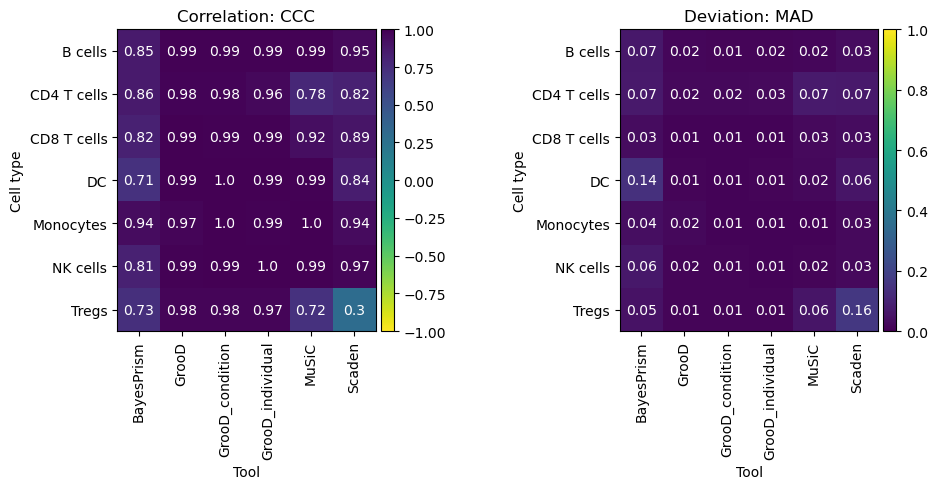

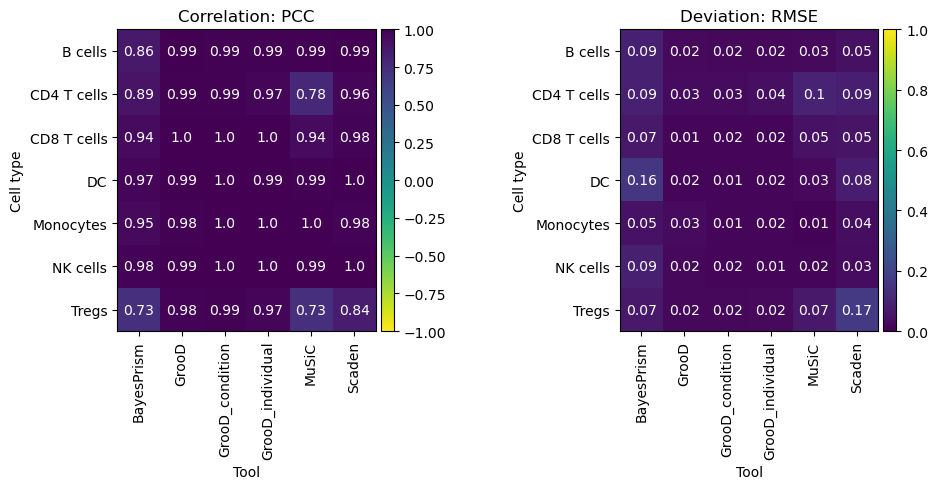

In [15]:
# Condition-specific pseudobulks

metrics_list = []

for tool in list(set(cond_pb['tool'])):
    
    df = cond_pb.loc[cond_pb['tool'] == tool]
    gt = cond_gt.loc[df.index.tolist(),:]
    gt.drop('data', axis=1, inplace=True)
    df = df[gt.columns.tolist()]

    metrics = getCorr(df, gt)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

# Changed function for annotated heatmap

def annotated_heatmap(df, m1, m2, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m1]]
        .pivot(index="Cell type", columns="Tool", values=m1)
    )
    df2 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m2]]
        .pivot(index="Cell type", columns="Tool", values=m2)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: {m1}')
    ax1.set_xlabel('Tool')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title(f'Deviation: {m2}')
    ax2.set_xlabel('Tool')
    ax2.set_ylabel('Cell type')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig('SI_Figure_3A_condition_pbs.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(complete_metrics, 'CCC', 'MAD', True)
annotated_heatmap(complete_metrics, 'PCC', 'RMSE')

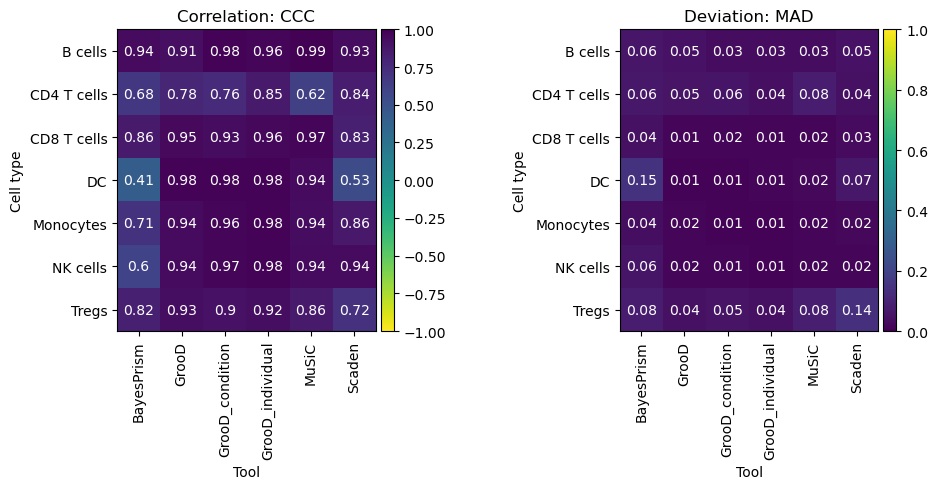

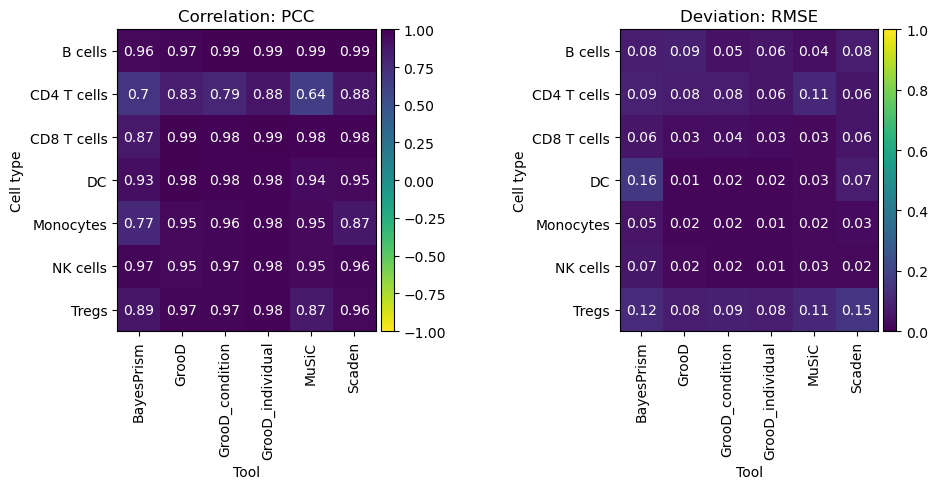

In [17]:
# Individual-specific pseudobulks

metrics_list = []

for tool in list(set(indiv_pb['tool'])):
    
    df = indiv_pb.loc[indiv_pb['tool'] == tool]
    gt = indiv_gt.loc[df.index.tolist(),:]
    gt.drop('data', axis=1, inplace=True)
    df = df[gt.columns.tolist()]

    metrics = getCorr(df, gt)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

# Changed function for annotated heatmap

def annotated_heatmap(df, m1, m2, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m1]]
        .pivot(index="Cell type", columns="Tool", values=m1)
    )
    df2 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m2]]
        .pivot(index="Cell type", columns="Tool", values=m2)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: {m1}')
    ax1.set_xlabel('Tool')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title(f'Deviation: {m2}')
    ax2.set_xlabel('Tool')
    ax2.set_ylabel('Cell type')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig('SI_Figure_3B_individual_pbs.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(complete_metrics, 'CCC', 'MAD', True)
annotated_heatmap(complete_metrics, 'PCC', 'RMSE')

### Figure 2C - Benchmark Hao Finotello

In [15]:
pred = pd.read_csv('../../grood_runs/revisions/hao_finotello/Finotello_counts_for_GRCh37_Hao_2_train_for_GRCh37_noMarkers_GCF_000001405.25_GRCh37.p13_genomic_Finotello_FACS_proportions_no_neutrophils_others_e1f2e9c7/evaluation/predictions_merged.csv', index_col=0)
pred.head()

,tool,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs
sample,,,,,,,,
pbmc_1,BayesPrism,0.023278,5.764560e-02,8.258504e-03,1.397786e-01,0.445482,0.325194,3.632727e-04
pbmc_10,BayesPrism,0.019806,3.479903e-02,7.647526e-03,1.658065e-01,0.551351,0.219436,1.153708e-03
pbmc_12,BayesPrism,0.014694,2.438038e-03,2.322860e-02,1.136644e-01,0.438156,0.407736,8.308241e-05
pbmc_2,BayesPrism,0.007604,1.150569e-03,7.744112e-05,1.346912e-01,0.423457,0.241335,1.916839e-01
pbmc_4,BayesPrism,0.013583,3.440445e-07,1.739214e-07,6.971307e-07,0.390152,0.596264,1.827438e-07


In [16]:
groundTruth = pd.read_csv('../../data/bulk_data/Finotello_2019/final_data/Finotello_FACS_proportions_no_neutrophils_others.csv', index_col=0)
groundTruth.head()

,NK cells,B cells,Tregs,DC,Monocytes,CD8 T cells,CD4 T cells
pbmc_1,0.0675,0.0581,0.0175,0.0160,0.2001,0.1564,0.3796
pbmc_10,0.0718,0.0640,0.0084,0.0227,0.3586,0.1839,0.1786
pbmc_12,0.1409,0.0516,0.0050,0.0426,0.2003,0.2984,0.1533
pbmc_2,0.1128,0.0296,0.0143,0.0234,0.2481,0.1638,0.2552
pbmc_4,0.1154,0.0384,0.0097,0.0357,0.1943,0.2452,0.2247


In [17]:
# Generate QC metrics per cell type and tool

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    cellTypes = groundTruth.columns.tolist()

    for cell in cellTypes:

        index_names = df.index.tolist()
        
        xdata = df.loc[index_names, cell].tolist()
        ydata = groundTruth.loc[index_names, cell].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = cellTypes

    return DF

# Loop over tools

metrics_list = []

for tool in list(set(pred['tool'])):
    
    df = pred.loc[pred['tool'] == tool]

    metrics = getCorr(df, groundTruth)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

,PCC,SCC,CCC,RMSE,RD,MAD,Tool
NK cells,0.329377,0.533333,0.074717,0.179039,-0.415311,0.138100,MuSiC
B cells,0.051894,-0.237322,0.014535,0.041342,2.389330,0.036021,MuSiC
Tregs,NaN,NaN,0.000000,0.010727,0.000000,0.010144,MuSiC
DC,-0.679912,-0.600000,-0.010037,0.305607,-0.892876,0.296605,MuSiC
Monocytes,0.886635,0.866667,0.397640,0.115090,-0.273985,0.103592,MuSiC


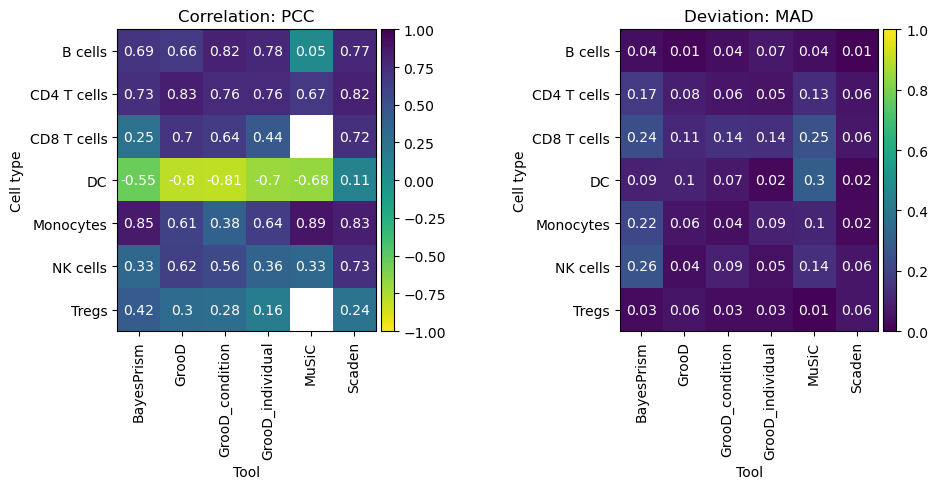

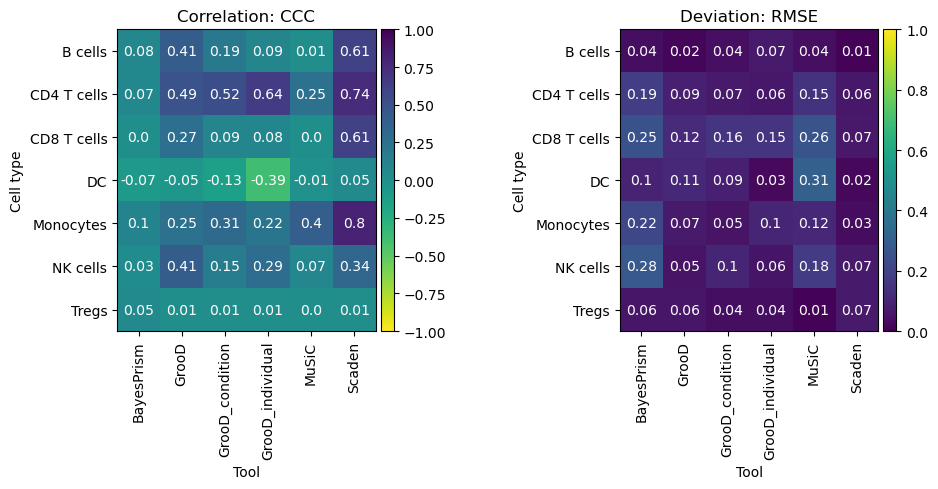

In [18]:
# Changed function for annotated heatmap

def annotated_heatmap(df, m1, m2, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m1]]
        .pivot(index="Cell type", columns="Tool", values=m1)
    )
    df2 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m2]]
        .pivot(index="Cell type", columns="Tool", values=m2)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: {m1}')
    ax1.set_xlabel('Tool')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title(f'Deviation: {m2}')
    ax2.set_xlabel('Tool')
    ax2.set_ylabel('Cell type')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig('Figure_2C.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(complete_metrics, 'PCC', 'MAD', True)
annotated_heatmap(complete_metrics, 'CCC', 'RMSE')

### Figure 2D - Deconvolution BIU - OConnell

In [19]:
# Get convolution results using Hao and Finotello data account for cell type proportions

pred = pd.read_csv('../../grood_runs/revisions/biu_oconnell/OConnel_raw_data_for_GRCh38_BIU_7_train_for_GRCh38_noMarkers_GCF_000001405.40_GRCh38.p14_genomic_OConnell_proportions_no_eosinophils_8492f6c9/evaluation/predictions_merged.csv', index_col=0)
# pred.drop(['Unknown'], axis=1, inplace=True)
pred.head()

,tool,Lymphocytes,Monocytes,Neutrophils
sample,,,,
SRR23992075_sorted.bam,BayesPrism,1.329482e-06,0.514189,0.485810
SRR23992076_sorted.bam,BayesPrism,2.116472e-02,0.519296,0.459539
SRR23992077_sorted.bam,BayesPrism,3.702175e-02,0.627519,0.335460
SRR23992078_sorted.bam,BayesPrism,9.188764e-07,0.579269,0.420730
SRR23992079_sorted.bam,BayesPrism,7.717526e-07,0.428495,0.571504


In [20]:
pred.index = [p.split("_")[0] for p in pred.index.tolist()]
pred

,tool,Lymphocytes,Monocytes,Neutrophils
SRR23992075,BayesPrism,1.329482e-06,0.514189,0.485810
SRR23992076,BayesPrism,2.116472e-02,0.519296,0.459539
SRR23992077,BayesPrism,3.702175e-02,0.627519,0.335460
SRR23992078,BayesPrism,9.188764e-07,0.579269,0.420730
SRR23992079,BayesPrism,7.717526e-07,0.428495,0.571504
...,...,...,...,...
SRR23992208,Scaden,2.342172e-01,0.471597,0.294186
SRR23992209,Scaden,5.223503e-01,0.391741,0.085909
SRR23992210,Scaden,3.112514e-01,0.307368,0.381380
SRR23992211,Scaden,3.887288e-01,0.303192,0.308079


In [21]:
groundTruth = pd.read_csv('../../data/bulk_data/OConnell_2024/OConnell_proportions_no_eosinophils.csv', index_col=0)
groundTruth

,Lymphocytes,Monocytes,Neutrophils
Run,,,
SRR23992103,0.059,0.030,0.905
SRR23992114,0.322,0.085,0.576
SRR23992093,0.273,0.061,0.620
SRR23992144,0.099,0.139,0.733
SRR23992210,0.207,0.052,0.731
...,...,...,...
SRR23992194,0.104,0.060,0.806
SRR23992178,0.271,0.070,0.655
SRR23992119,0.234,0.094,0.640


In [22]:
# Generate QC metrics per cell type and tool

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    samples = groundTruth.index.tolist()

    for sample in samples:
        
        xdata = df.loc[sample].tolist()
        ydata = groundTruth.loc[sample].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = samples

    return DF

# Loop over tools

metrics_list = []

for tool in list(set(pred['tool'])):
    
    df = pred.loc[pred['tool'] == tool]
    df.drop(['tool'], axis=1, inplace=True)
    df.sort_index(axis=1, inplace=True)
    gt = groundTruth
    gt.sort_index(axis=1, inplace=True)

    metrics = getCorr(df, gt)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

,PCC,SCC,CCC,RMSE,RD,MAD,Tool
SRR23992103,-0.525052,-0.866025,-0.519209,0.766682,-0.323333,0.644667,MuSiC
SRR23992114,-0.855860,-0.866025,-0.616412,0.651328,-0.305000,0.604333,MuSiC
SRR23992093,-0.788680,-0.866025,-0.621787,0.668493,-0.313000,0.610667,MuSiC
SRR23992144,-0.450424,0.000000,-0.401852,0.655340,-0.287000,0.564333,MuSiC
SRR23992210,-0.676623,-0.866025,-0.604404,0.701407,-0.316000,0.628667,MuSiC


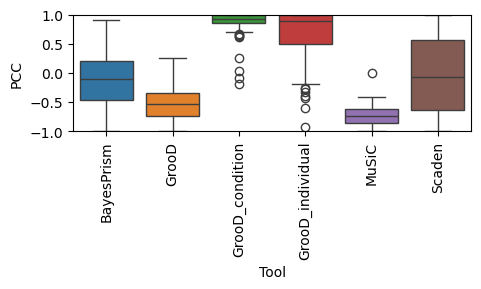

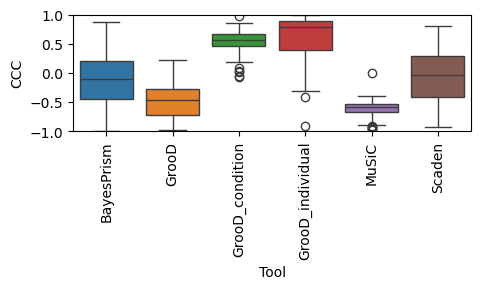

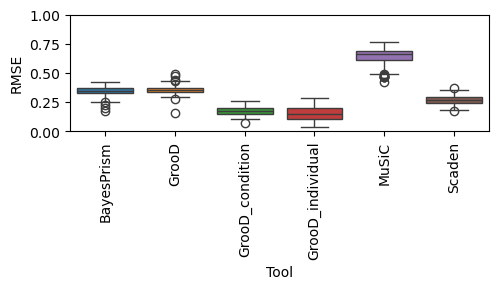

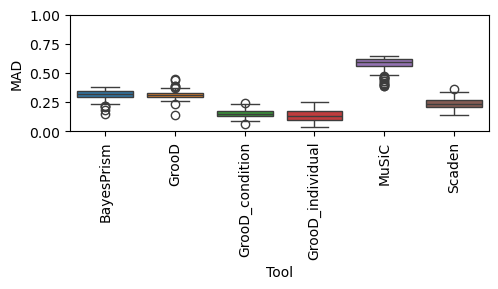

In [23]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df, metric, plot=False):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """

    df.sort_values(by=['Tool'], inplace=True)

    plt.figure(figsize=(5,3))
    p = sns.boxplot(data=df, x = "Tool", y = metric, hue = "Tool")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    if metric in ['RMSE', 'MAD']:
        p.set_ylim([0,1])
    else:
        p.set_ylim([-1,1])
    plt.tight_layout()
    if plot:
        plt.savefig(f'Figure_2D_{metric}.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(complete_metrics, 'PCC')
boxplot_metrics(complete_metrics, 'CCC', True)
boxplot_metrics(complete_metrics, 'RMSE')
boxplot_metrics(complete_metrics, 'MAD', True)

### SI Figure 3B (part 1 on cell type metrics)

In [24]:
# Generate QC metrics per cell type and tool

def getCorr(df, groundTruth):

    """
    Computes correlation and error metrics for predicitions vs. ground-truth as stored in the MasterTable
    df: predictions
    groundTruth
    """


    rsquared = []
    cccs = []
    rmses = []
    spearmans = []
    percent_dev = []
    absol_dev = []

    # Concordance correlation coefficient
    def ccc(x_data,y_data):
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rhoc = 2*sxy / (np.var(x_data) + np.var(y_data) + (np.mean(x_data) - np.mean(y_data))**2)
        return rhoc


    # Pearson Correlation Coefficient
    def r(x_data,y_data):
        ''' Pearson Correlation Coefficient'''
        sxy = np.sum((x_data - np.mean(x_data))*(y_data - np.mean(y_data)))/len(x_data)
        rho = sxy / (np.std(x_data)*np.std(y_data))
        return rho


    # RMSE
    def rmse(x_data,y_data):
        MSE = np.mean(np.square((np.array(x_data)-np.array(y_data))))
        RMSE = np.sqrt(MSE)
        return RMSE

    # Spearmans rank correlation    
    def spearman(x_data, y_data):
        spearmanCorr, _ = stats.spearmanr(np.array(x_data), np.array(y_data))
        return spearmanCorr
    
    # Percent deviation function
    def frac_deviation(x_data, y_data):
        frac_devs = np.mean(np.divide((np.array(y_data) - np.array(x_data)),np.array(x_data), where=(np.array(x_data)!=0)))
        return frac_devs # for sparse data, quite some data points might be excluded due to the removal of 0-divisions from the mean
    
    # Absolute deviation function
    def abs_deviation(x_data, y_data):
        abs_devs = np.mean(abs(np.array(y_data) - np.array(x_data)))
        return abs_devs

    cellTypes = groundTruth.columns.tolist()

    for cell in cellTypes:

        index_names = df.index.tolist()
        
        xdata = df.loc[index_names, cell].tolist()
        ydata = groundTruth.loc[index_names, cell].tolist()
        b = r(xdata, ydata)
        rsquared.append(b)
        s = spearman(xdata, ydata)
        spearmans.append(s)
        c = ccc(xdata, ydata)
        cccs.append(c)
        a = rmse(xdata, ydata)
        rmses.append(a)
        f = frac_deviation(xdata, ydata)
        percent_dev.append(f)
        g = abs_deviation(xdata, ydata)
        absol_dev.append(g)

    DF = pd.concat([pd.Series(rsquared), pd.Series(spearmans), pd.Series(cccs), pd.Series(rmses), pd.Series(percent_dev), pd.Series(absol_dev)], axis = 1, ignore_index = True)
    DF.columns = ['PCC', 'SCC', 'CCC', 'RMSE', 'RD', 'MAD']
    DF.index = cellTypes

    return DF

# Loop over tools

metrics_list = []

for tool in list(set(pred['tool'])):
    
    df = pred.loc[pred['tool'] == tool]
    df.drop(['tool'], axis=1, inplace=True)
    df.sort_index(axis=1, inplace=True)
    gt = groundTruth
    gt.sort_index(axis=1, inplace=True)

    metrics = getCorr(df, gt)
    metrics['Tool'] = tool

    metrics_list.append(metrics)

complete_metrics = pd.concat(metrics_list, axis=0)
complete_metrics.head()

,PCC,SCC,CCC,RMSE,RD,MAD,Tool
Lymphocytes,0.501622,0.604148,0.165467,0.219871,27.447091,0.199287,MuSiC
Monocytes,0.061028,0.076862,0.000447,0.877376,-0.918228,0.872422,MuSiC
Neutrophils,-0.005077,0.025138,-0.000021,0.656145,NaN,0.645216,MuSiC
Lymphocytes,0.570353,0.589166,0.249149,0.108768,0.289864,0.088104,GrooD
Monocytes,0.252856,0.338226,0.001521,0.464122,-0.857679,0.462949,GrooD


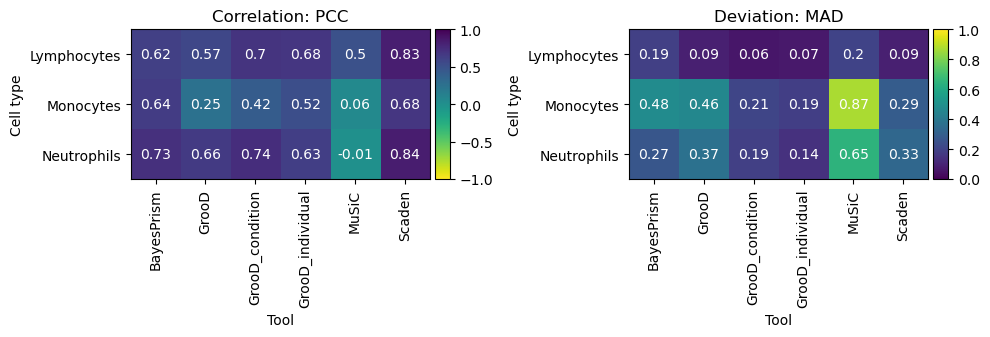

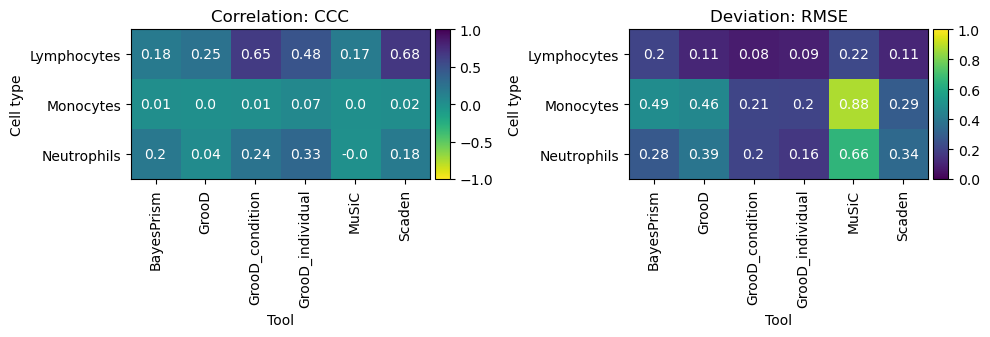

In [25]:
# Changed function for annotated heatmap

def annotated_heatmap(df, m1, m2, plot=False):

    """"
    Visualizes correlation and error metrics computed with getCorr in heatmaps with fixed scales
    df: output from getCorr
    """

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    df1 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m1]]
        .pivot(index="Cell type", columns="Tool", values=m1)
    )
    df2 = (
        df.reset_index(names="Cell type")[["Cell type", "Tool", m2]]
        .pivot(index="Cell type", columns="Tool", values=m2)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    im1 = ax1.imshow(df1, vmin=-1, vmax=1, cmap='viridis_r')

    for i in range(df1.shape[0]):
        for j in range(df1.shape[1]): 
            ax1.annotate(str(round(df1.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax1.set_title(f'Correlation: {m1}')
    ax1.set_xlabel('Tool')
    ax1.set_ylabel('Cell type')
    ax1.set_yticks(range(df1.shape[0]), df1.index.tolist())
    ax1.set_xticks(range(df1.shape[1]), df1.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax = cax, ax = ax1)

    im2 = ax2.imshow(df2, vmin=0, vmax=1, cmap='viridis')

    for i in range(df2.shape[0]):
        for j in range(df2.shape[1]): 
            ax2.annotate(str(round(df2.iloc[i,j], 2)), xy=(j, i), 
                        ha='center', va='center', color='white')

    ax2.set_title(f'Deviation: {m2}')
    ax2.set_xlabel('Tool')
    ax2.set_ylabel('Cell type')
    ax2.set_yticks(range(df2.shape[0]), df2.index.tolist())
    ax2.set_xticks(range(df2.shape[1]), df2.columns.tolist(), rotation = 'vertical')
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im2, cax = cax, ax = ax2)

    plt.tight_layout()
    if plot:
        plt.savefig(f"SI_Figure_3B_{m1}_{m2}.svg", transparent = True, dpi = 300, format = 'svg')
    plt.show()

annotated_heatmap(complete_metrics, 'PCC', 'MAD', True)
annotated_heatmap(complete_metrics, 'CCC', 'RMSE')

### SI Figure 3A

In [26]:
# Get convolution results using Hao and Finotello data account for cell type proportions
eval_res = pd.read_csv('../../../Convolution_control/nf_conv_02_2026/results_admiring_gates/BIU_OConnel/viz_inter/viz_inter/OConnell_TPM_data_BIU_7_train_for_GRCh38_metrics.csv', index_col=0)
# eval_res = eval_res.loc[eval_res['filter_strategy'] == 'mRNA']
eval_res = eval_res.loc[eval_res['space'] == 'CPM']
eval_res = eval_res.loc[eval_res['metric'].isin(['Pearson', 'CCC', '1-JSD'])]
eval_res.replace({'Pearson' : 'PCC'}, inplace=True)
eval_res.replace({'none' : 'all', 'mRNA' : 'coding only'}, inplace=True)
eval_res.head()

,dataset,space,metric,value
0,ConvolutionLike,CPM,1-JSD,0.584611
1,ConvolutionLike,CPM,PCC,0.541635
3,ConvolutionLike,CPM,CCC,0.512674
8,ConvolutionLike,CPM,1-JSD,0.567166
9,ConvolutionLike,CPM,PCC,0.462775


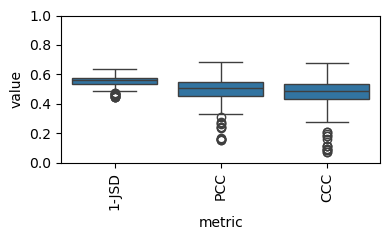

In [27]:
# Plot to visualize distribution of quality metrics

def boxplot_metrics(df):

    """
    Creates boxplot of proportions per cell type across samples in pred
    pred: samples x cell types pandas dataframe
    output: target directory
    """
    plt.figure(figsize=(4,2.5))
    p = sns.boxplot(data=df, x = "metric", y = "value")
    p.set_xticklabels(p.get_xticklabels(), rotation=90)
    p.set_ylim([0,1])
    # plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title = 'Gene subset')
    plt.tight_layout()
    plt.savefig('SI_Figure_3A.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

boxplot_metrics(eval_res)